<center><h1> Three-Eloop </h1></center>

In [1]:
from MCA_lib1_2 import *
import pennylane as qml
import warnings
warnings.filterwarnings('ignore')

## Variables Input

In [2]:
# Number of desired symbols
num_ext_edges=4
num_int_edges=5
num_edges =num_ext_edges+num_int_edges

num_no_reverse_clauses = 15

num_propagator_edge = 2

needs_extra_qubit = True

name_diagram = '4s18u'

num_shots = 30000000

cut = 40

## Logical Variables

In [3]:
# Lista para almacenar los símbolos con subíndices
S = make_edges(num_edges)
Sp = make_prime_edges(S)

Set_edges = make_set_edges(S,Sp)

# Ancilla qubits

c = [symbols('c_{}'.format(i)) for i in range(0, num_no_reverse_clauses)]

## Llenado de Ancilla qubits y creación de resultados

In [4]:
# Definir auxiliares

c[0] = And(S[0], S[1], S[2], S[3])

c[1] = And(S[0],Sp[4], S[5],Sp[8])

c[2] = And(S[1],Sp[5],S[6], S[8]) #15

c[3] = And(S[2], Sp[6], S[7],Sp[8]) #16

c[4] = And(S[3], S[4], Sp[7],S[8]) #17

c[5] = And(S[0],S[1], Sp[4], S[6])

c[6] = And(S[1],S[2], Sp[5], S[7]) #18

c[7] = And(S[2],S[3], S[4], Sp[6]) #19

c[8] = And(S[0],S[3], S[5], Sp[7]) 

c[9] = And(S[0],S[1], S[2], Sp[4], S[7],Sp[8])

c[10] = And(S[1],S[2], S[3], S[4],Sp[5],S[8]) #20

c[11] = And(S[0],S[2], S[3], S[5], Sp[6],Sp[8])

c[12] = And(S[0],S[1], S[3], S[6],Sp[7],S[8])

c[13] = And(S[1], Sp[3], Sp[4],Sp[5],S[6],S[7]) #21

c[14] = And(S[0],Sp[2], Sp[4], S[5],S[6],Sp[7])

######################## Total ######################

clauses = [*c, *reverse_clauses(c, S, Sp)]

## Matriz de adyacencia - Clausulas

In [5]:
Graph_matrix_clauses = adjacent_matrix_clauses(clauses, Set_edges)
Graph_matrix_clauses

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
        1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0.,
        1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1.,
        0., 1., 1., 0., 1., 1.],
       [0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0.,
        1., 0., 1., 1., 1., 1.],
       [0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1.,
        0., 1., 0., 1., 1., 0.],
       [0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1.,
        0., 0., 1., 0., 1., 1.],
       [0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1.,
        1., 0., 1., 1., 1., 1.],
       [0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0.,
        1., 1., 1., 1., 1., 0.],
       [0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0.,
        0., 1., 0., 1., 1., 0.],
       [0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0.,

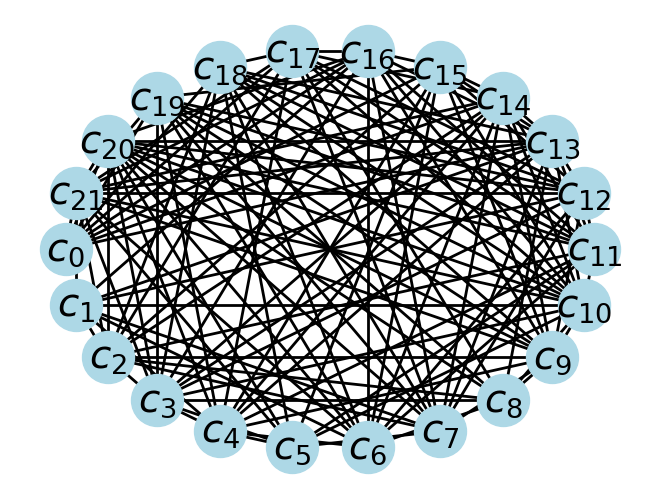

In [6]:
graph_clauses = graph_clauses(clauses, Set_edges, draw = True, name_graph = '3e9_clauses')

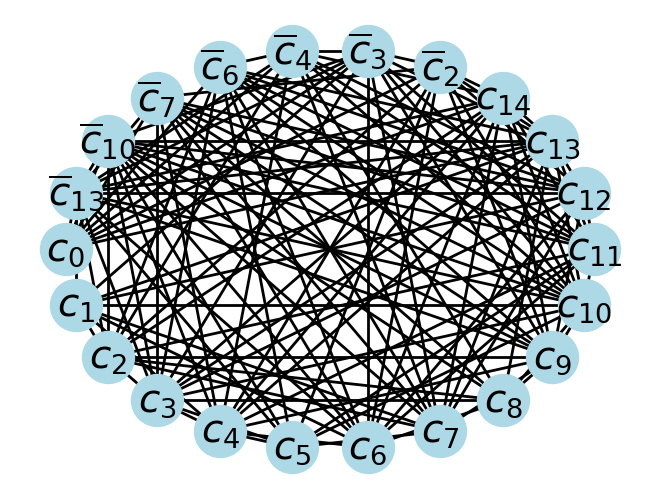

In [7]:
graph_clausesR = graph_clauses_Rev(S,c,clauses, Set_edges, draw = True, name_graph = '3e9_ClausesRev')

[[10, 13, 3, -10, -3, -13],
 [2, 11, -4, -6],
 [-2, 4, 9, -7],
 [6, 1, 12],
 [0, 14],
 [5, 7],
 [8]]

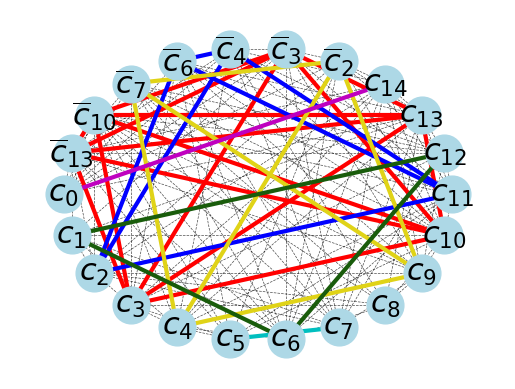

In [8]:
graph_clausesC = graph_clauses_C(S,c,clauses, Set_edges, draw = True, name_graph = '3e9_Clauses_cliques')
graph_clausesC[1]

In [9]:
clauses_combination = Graph_condition_combination(graph_clauses,clauses,S,c)
clauses_combination

([[10, 13, 3, 20, 16, 21],
  [2, 11, 17, 18],
  [15, 4, 9, 19],
  [6, 1, 12],
  [0, 14],
  [5, 7],
  [8]],
 [[10, 13, 3, -10, -3, -13],
  [2, 11, -4, -6],
  [-2, 4, 9, -7],
  [6, 1, 12],
  [0, 14],
  [5, 7],
  [8]])

## Depth

In [10]:
Graph_matrix_depth = adjacent_matrix_depth(clauses, Set_edges)

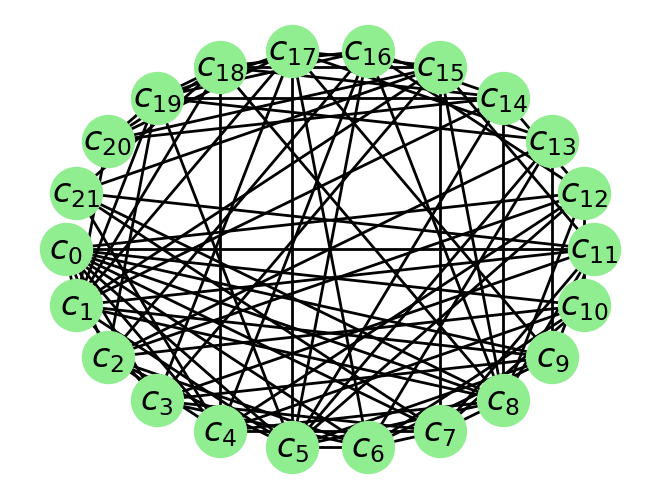

In [11]:
graph_depth = graph_depth(clauses, Set_edges, draw = True, name_graph = 'xmen_depht')

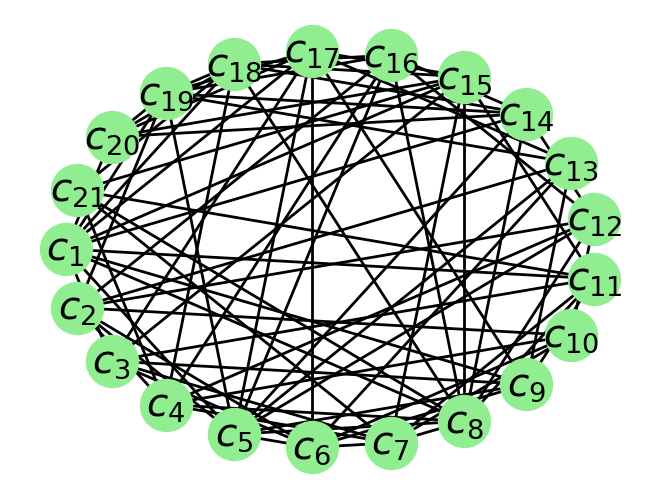

In [12]:
graph_depth3 = graph_depth3(clauses,num_ext_edges ,Set_edges, draw = True)

[[0],
 [1, 14, -6, -7, -10],
 [5, 9, -4, 13, 6],
 [11, 7, -2, -13, 8],
 [2, 4, 12, 10],
 [3],
 [-3]]

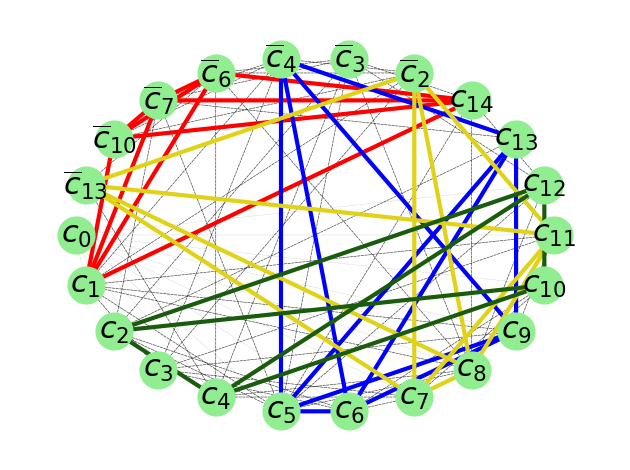

In [13]:
graph_depthf=graph_depthC(S,c,clauses,num_ext_edges,Set_edges, draw = True,name_graph = '3e9')
graph_depthf[1]

In [14]:
depth_combination = Graph_condition_combination(graph_depth,clauses,S,c)
depth_combination

([[0, 3, 9, 1, 11],
  [5, 8, 16, 12, 14],
  [2, 19, 13],
  [17, 20, 15],
  [4, 10, 7],
  [18, 21],
  [6]],
 [[0, 3, 9, 1, 11],
  [5, 8, -3, 12, 14],
  [2, -7, 13],
  [-4, -10, -2],
  [4, 10, 7],
  [-6, -13],
  [6]])

In [15]:
depth_combination3 = Graph_condition_combination3(graph_depth3,clauses, num_ext_edges,S,c)
depth_combination3
#[[3], [0, 4], [1, 5], [2]]


([[0],
  [1, 14, 18, 19, 20],
  [5, 9, 17, 13, 6],
  [11, 7, 15, 21, 8],
  [2, 4, 12, 10],
  [3],
  [16]],
 [[0],
  [1, 14, -6, -7, -10],
  [5, 9, -4, 13, 6],
  [11, 7, -2, -13, 8],
  [2, 4, 12, 10],
  [3],
  [-3]])

<left><h2> Qubits </h2></left>

In [16]:
# Numbers of qubits to use
num_auxs = len(clauses_combination[0])

# Qubits
edges_to_propag, e = edges_to_propagators(S, num_propagator_edge = num_propagator_edge)
clauses_to_aux,a = clauses_auxiliar(clauses, clauses_combination[0])

mark = 'out'


# Wires

total_wires = [*e, *a, mark]
init_states_wires = e

multi_controll_wires = [e[0], *a, mark]

if needs_extra_qubit:
    extra = 'extra'
    total_wires.insert(0, extra)
    init_states_wires.insert(0, extra)
    multi_controll_wires.insert(0, extra)

# Circuit

In [17]:
dev = qml.device('default.qubit', wires = total_wires, shots = num_shots)
qml.templates.GroverOperator.__name__ = "Diffusion Operator"

def circuit_function(depth_combination3):
    @qml.transforms.cancel_inverses
    @qml.qnode(dev)
    def circuit():
        #State preparation
        qml.broadcast(qml.Hadamard, init_states_wires, 'single')
        qml.broadcast(qml.PauliX, a, 'single')
        qml.PauliX(wires = mark)
        qml.Hadamard(wires = mark)
        # Oracle
        oracle(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        #
        qml.MultiControlledX(wires = multi_controll_wires)
        # Adjoint Oracle
        qml.simplify(qml.adjoint(oracle))(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        # Grover Diffuser
        qml.templates.GroverOperator(wires=init_states_wires)
        return qml.counts(wires = init_states_wires)
    return circuit

In [18]:
circuit3 = circuit_function([[4, 10, 12, 2], [0], [7, 15, 11, 21, 8], [16], [5, 17, 6, 13, 9], [3], [1, 19, 14, 18, 20]])

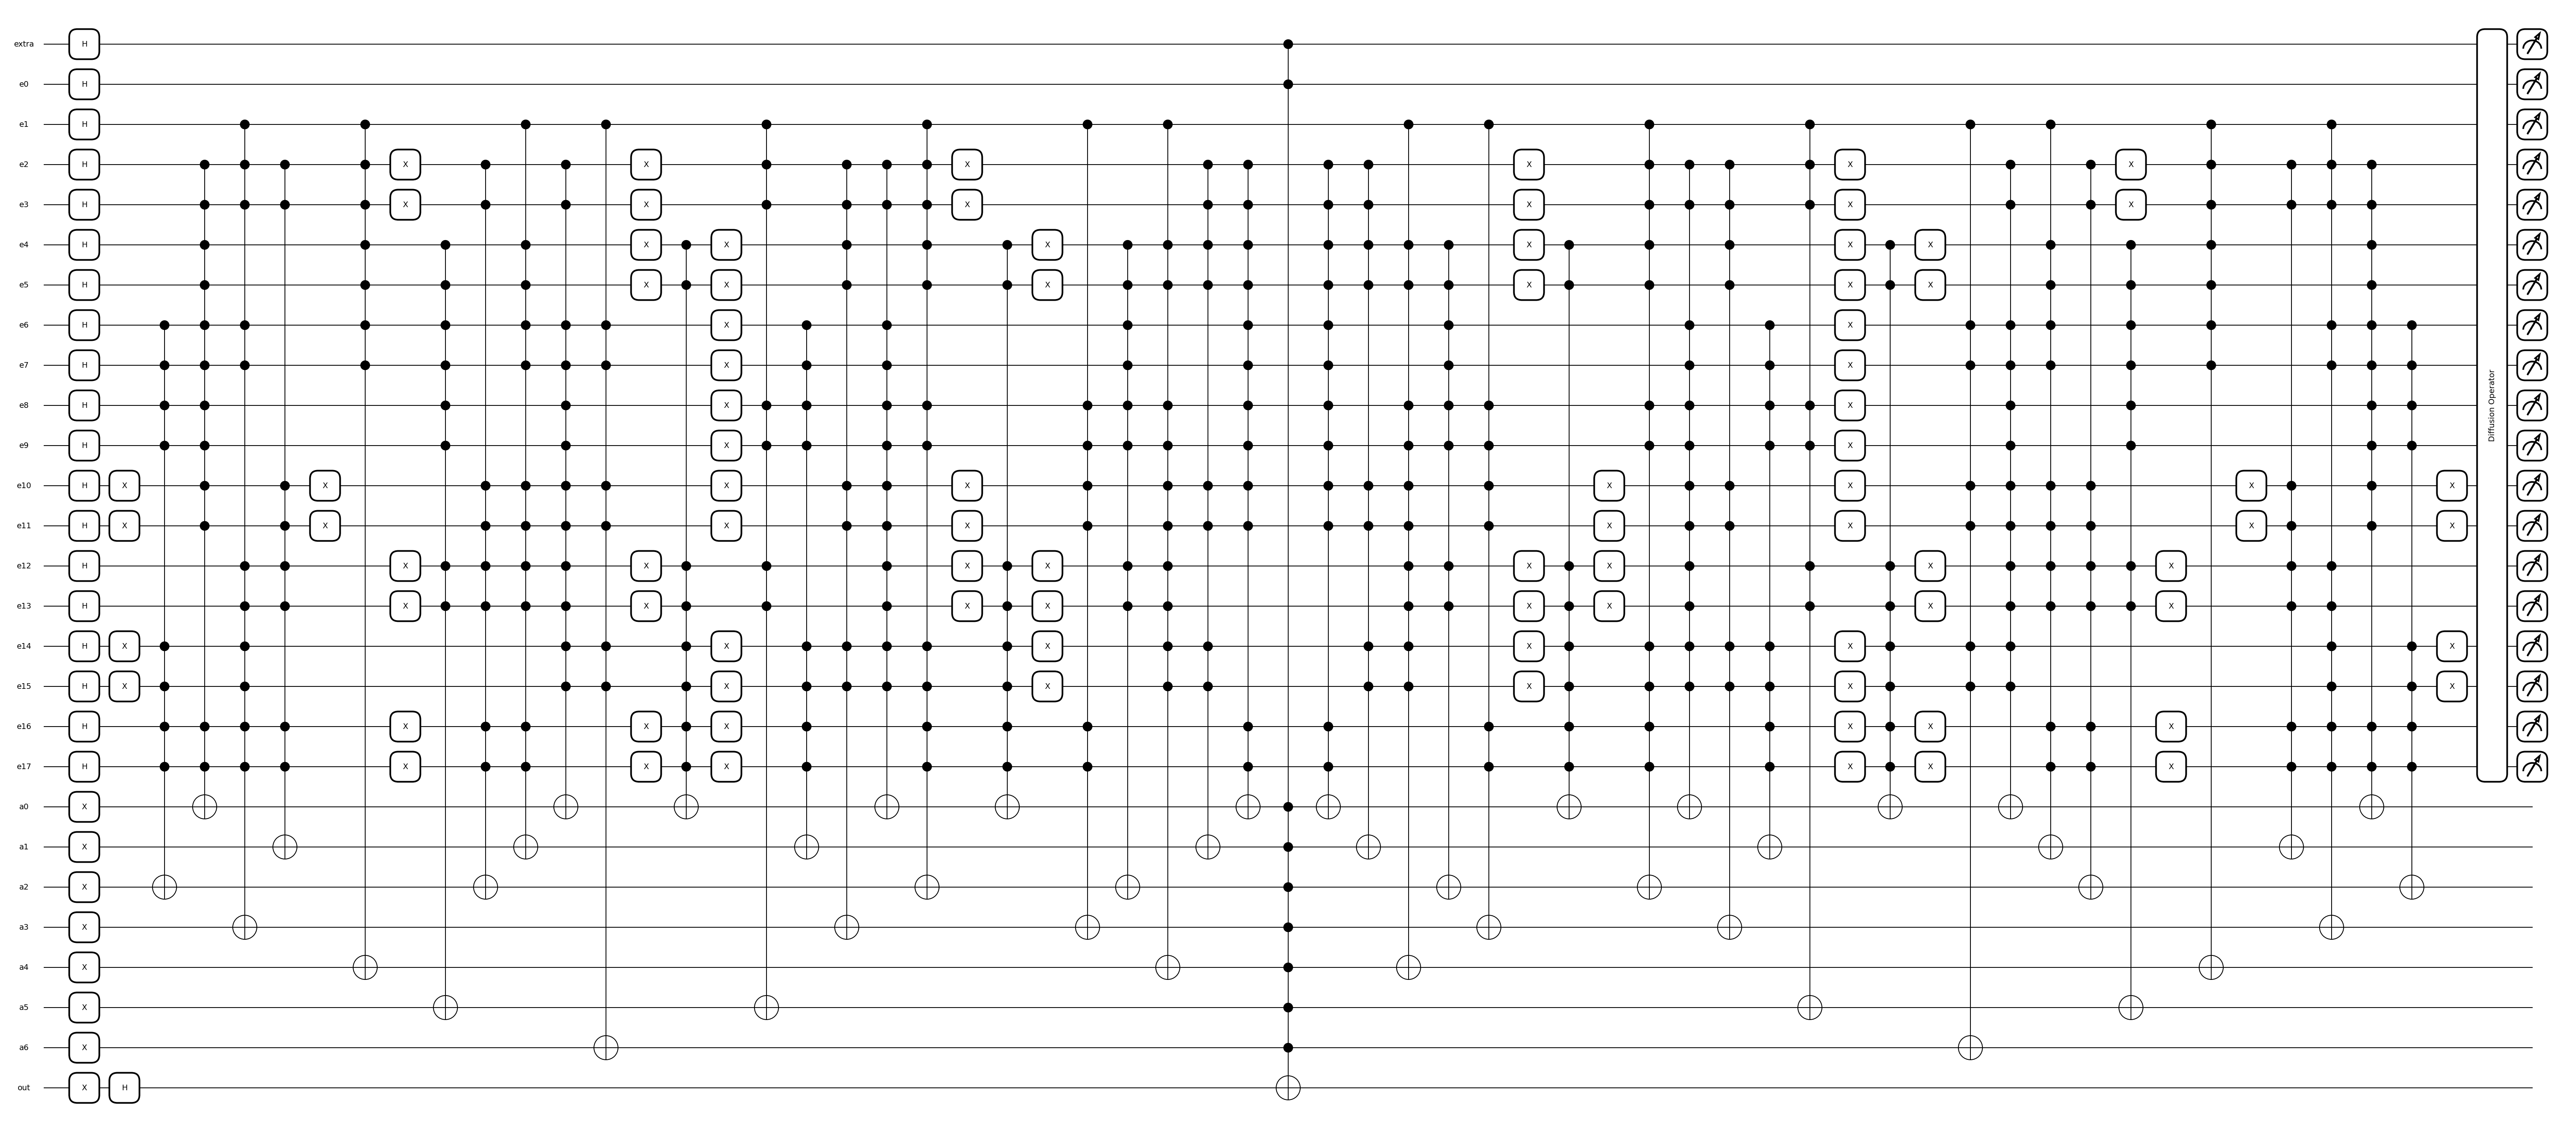

In [19]:
Draw_circuit(circuit3, wire_order_list= total_wires, name_file = name_diagram)

In [20]:
get_depth(circuit3)

The depth of the circuit is: 49


In [21]:
#num_casual_states(circuit3(), cut = 300)

# Optimization

## OPTUNA

In [22]:
import itertools
import optuna
import math

# List of original subsets
subconjuntos_base = depth_combination3[0]


# Precomputes the permutations of each subset (as a list of tuples)
permutaciones_por_subconjunto = [
    list(itertools.permutations(sub)) for sub in subconjuntos_base
]

# Precomputes the number of permutations of each subset
num_permutaciones = [len(p) for p in permutaciones_por_subconjunto]

# Total amount of permutations with a subset order fixed
total_comb_internas = math.prod(num_permutaciones)

# Amount of subset permutations
total_ordenes = math.factorial(len(subconjuntos_base))

# Total amount of possible permutations (not all permutations are generated)
espacio_total = total_comb_internas * total_ordenes

# Función ficticia a optimizar (reemplaza esto con tu lógica real)
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

# Decodificar un índice entero único en una combinación (sin generar todas)
def decodificar_combinacion(idx):
    n = len(subconjuntos_base)

    # Obtener el orden de los subconjuntos (perm index → permutación)
    orden_idx = idx % total_ordenes
    comb_idx = idx // total_ordenes

    orden = list(itertools.permutations(range(n)))[orden_idx]

    # Decodes internal indices for each subset
    indices_internos = []
    for i in reversed(range(n)):
        p = num_permutaciones[i]
        indices_internos.append(comb_idx % p)
        comb_idx //= p
    indices_internos = list(reversed(indices_internos))

    # Constructs the last combination
    combinacion = [list(permutaciones_por_subconjunto[i][indices_internos[i]]) for i in orden]
    return combinacion

# Función de evaluación para Optuna
def objective(trial):
    idx = trial.suggest_int("idx", 0, espacio_total - 1)
    combinacion = decodificar_combinacion(idx)
    return depth_circuit(combinacion)

# Executes the optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=2000)  # Adjust the number of trials

# Shows the best value
best_idx = study.best_params["idx"]
best_combination = decodificar_combinacion(best_idx)
print("Best combination:", best_combination)
print("Minimum value:", study.best_value)


[I 2026-04-22 15:16:34,444] A new study created in memory with name: no-name-95be3ca4-2a9b-46f8-9ee6-6aa464ec75f4
[I 2026-04-22 15:16:34,467] Trial 0 finished with value: 59.0 and parameters: {'idx': 59827676854}. Best is trial 0 with value: 59.0.
[I 2026-04-22 15:16:34,485] Trial 1 finished with value: 55.0 and parameters: {'idx': 27962974173}. Best is trial 1 with value: 55.0.
[I 2026-04-22 15:16:34,520] Trial 2 finished with value: 59.0 and parameters: {'idx': 11751865612}. Best is trial 1 with value: 55.0.
[I 2026-04-22 15:16:34,671] Trial 3 finished with value: 55.0 and parameters: {'idx': 199220349832}. Best is trial 1 with value: 55.0.
[I 2026-04-22 15:16:34,687] Trial 4 finished with value: 53.0 and parameters: {'idx': 191738244999}. Best is trial 4 with value: 53.0.
[I 2026-04-22 15:16:34,721] Trial 5 finished with value: 55.0 and parameters: {'idx': 68342361778}. Best is trial 4 with value: 53.0.
[I 2026-04-22 15:16:34,732] Trial 6 finished with value: 55.0 and parameters: {'

Best combination: [[0], [3], [20, 1, 18, 14, 19], [13, 17, 6, 5, 9], [11, 21, 7, 15, 8], [16], [12, 2, 4, 10]]
Minimum value: 49.0


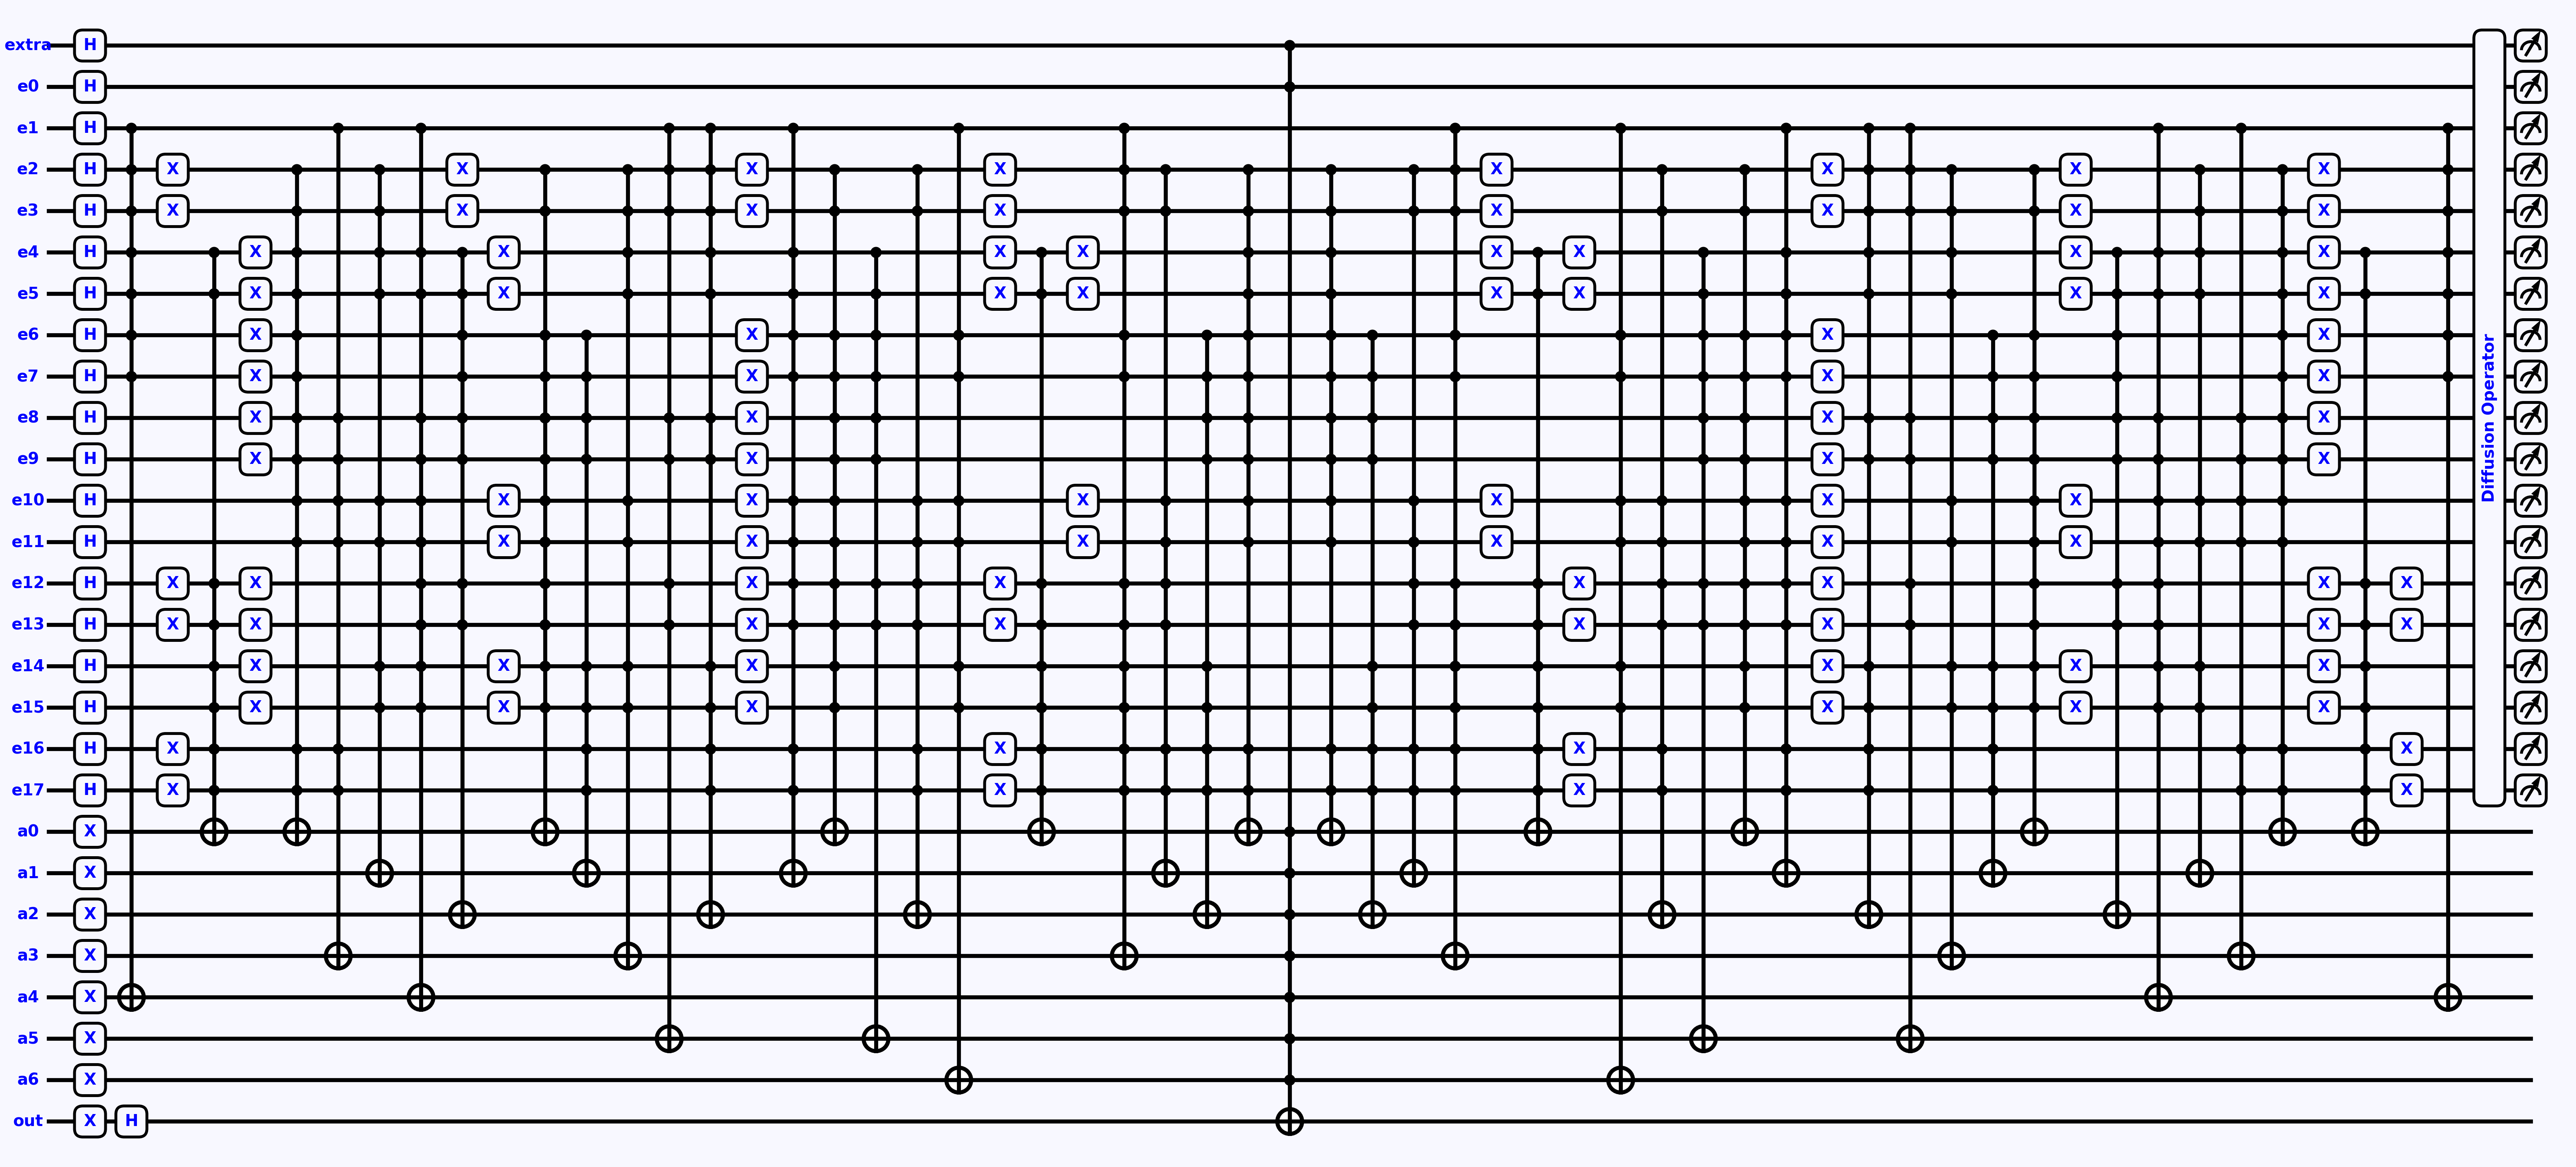

The depth of the circuit is: 49


In [23]:
circuit_D = circuit_function(best_combination)
Draw_circuit2(circuit_D, wire_order_list= total_wires, name_file = name_diagram)
get_depth(circuit_D)